In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy
from functools import reduce

from torch import nn
import pickle as pkl
from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model
from utils import cosine_similarity, get_r_2, vector_angle, flatten_list
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [4]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


def multiclass_functional_margin(W, x, y):
    W = W / np.linalg.norm(W)
    scores = x@W  # shape (K,)
    true_score = scores[y]
    max_other_score = np.max(np.delete(scores, y))
    return true_score - max_other_score


def train_svm(X, y):
    X_train = torch.tensor(X, dtype=torch.float32)
    y_train = torch.tensor(y, dtype=torch.long)

    num_classes = len(np.unique(y))
    num_features = X.shape[1]

    # 2. One-vs-Rest Linear SVM model
    class OvRLinearSVM(nn.Module):
        def __init__(self, in_features, num_classes):
            super().__init__()
            self.weights = nn.Parameter(torch.zeros(num_classes, in_features))
            self.biases = nn.Parameter(torch.zeros(num_classes))

        def forward(self, x):
            return x @ self.weights.t() # + self.biases  # shape: (batch, num_classes)

    model = OvRLinearSVM(num_features, num_classes)

    # 3. Define Hard-Margin Hinge Loss (no slack)
    def hard_margin_loss(outputs, labels):
        """
        Multi-class One-vs-Rest hard-margin hinge loss.
        """
        n = outputs.shape[0]
        true_class_scores = outputs[torch.arange(n), labels].unsqueeze(1)  # (n, 1)
        margins = outputs - true_class_scores + 1  # delta=1
        margins[torch.arange(n), labels] = 0  # Don't penalize correct class
        loss = torch.sum(torch.clamp(margins, min=0)) 
        return loss

    # 4. Training Loop
    loss_l = []
    accuracy_l = []
    optimizer = optim.SGD(model.parameters(), lr=1e-1)
    num_epochs = 100000
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = hard_margin_loss(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Enforce hard-margin constraint: no slack
        with torch.no_grad():
            outputs = model(X_train)
            true_class_scores = outputs[torch.arange(len(y_train)), y_train]
            other_class_scores = torch.cat([
                outputs[i, torch.arange(num_classes) != y_train[i]]
                for i in range(len(y_train))
            ]).view(len(y_train), -1)
                # break
        loss_l.append(loss.item())
        pred = torch.argmax(outputs, dim=1)
        acc = (pred == y_train).float().mean()
        accuracy_l.append(acc.item())
        # if epoch % (num_epochs//10) == 0:
        #     print(f"Epoch {epoch}, Loss: {loss.item():.2f}, Train Acc: {acc:.2f}")

    # Final evaluation
    with torch.no_grad():
        preds = torch.argmax(model(X_train), dim=1)
        accuracy = (preds == y_train).float().mean()

        if torch.all(true_class_scores.unsqueeze(1) > other_class_scores + 1):
            print(f"Hard margin separation achieved")
        print(f"\nFinal training accuracy: {accuracy:.2f}")
    
    W = model.weights.detach().numpy()
    margins = np.mean([multiclass_functional_margin(W.T, x_curr, y_curr) for x_curr, y_curr in zip(X, y)])
    return margins, W

Hard margin separation achieved

Final training accuracy: 1.00


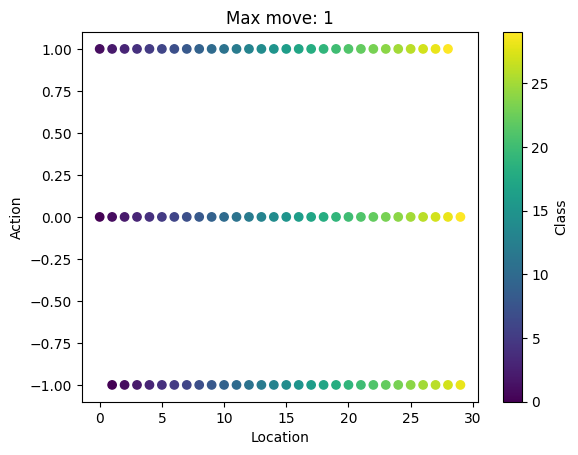

In [ ]:
C = Config()

C.length_corridors = [30]
max_move_l = [1, C.length_corridors[0]//2]
W_l = []
for max_move in max_move_l:
    C.max_move = max_move

    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

    X_np = X
    y_np = y
    y = y.argmax(1)
    margins, W = train_svm(X, y)
    W_l.append(W)
    # Standardize features (important for SVMs)
    # scaler = StandardScaler()
    # INSERT_YOUR_CODE
    plt.scatter(loc_X, action_taken, c=loc_y)
    plt.xlabel('Location')
    plt.ylabel('Action')
    plt.title(f'Max move: {max_move}')
    plt.colorbar(label='Class')
    plt.show()